In [1]:
import numpy as np
import matplotlib.pyplot as plt

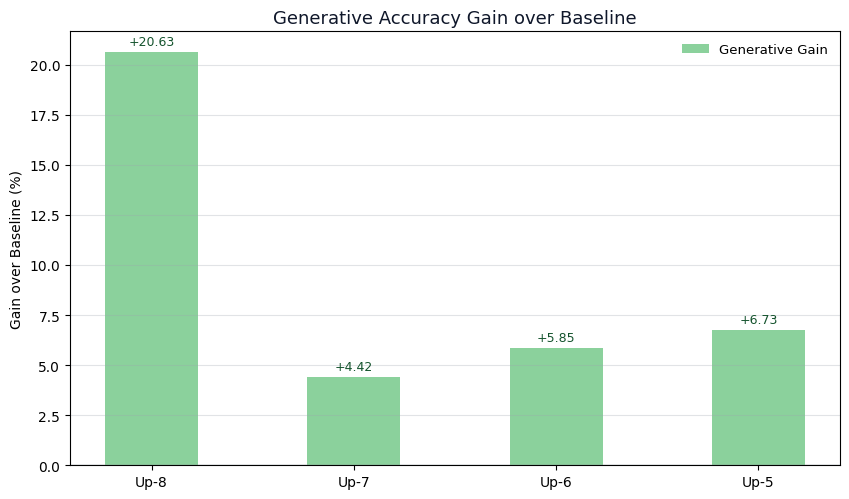

In [ ]:
# baseline vs generative (accuracy)
thresholds = ['[ 0.8, 1 ]', '[ 0.7, 1 ]', '[ 0.6, 1 ]', '[ 0.5, 1 ]']

base_acc = np.array([63.41, 79.98, 74.26, 78.71])
gen_acc = np.array([84.04, 84.40, 80.11, 85.44])

x = np.arange(len(thresholds))
g_gain = gen_acc - base_acc

# accuracy gain over baseline (generative only)
fig, ax = plt.subplots(figsize=(8.6, 5.1))
bar_w = 0.46
bars = ax.bar(x, g_gain, width=bar_w, color="#8BD19C", label='Generative Gain')

for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h + 0.20,
        f"+{h:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        color="#14532D"
    )

ax.axhline(0, color="#9CA3AF", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.set_ylabel('Gain over Baseline (%)')
ax.set_title('Generative Accuracy Gain over Baseline', fontsize=13, color="#0F172A")
ax.grid(axis='y', alpha=0.30, color="#9CA3AF")
ax.legend(frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()

/var/folders/y6/v08pgd9n6f32p2hsb0h872_h0000gn/T/ipykernel_4265/2807374983.py:70: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0.06, 0.08, 1.0, 0], h_pad=3.2, w_pad=2.4)


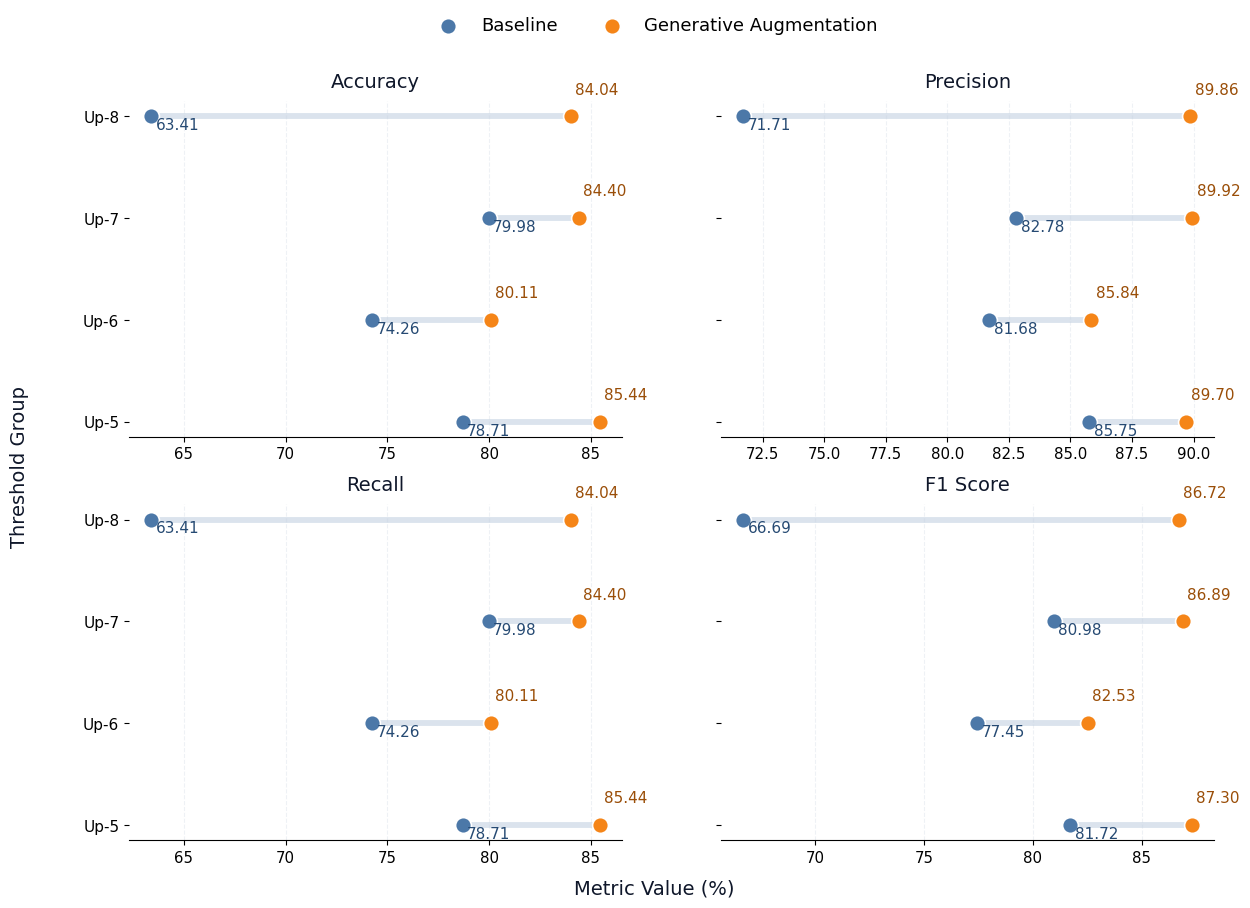

In [3]:
x = np.arange(len(thresholds))

# baseline
base_acc = np.array([63.41, 79.98, 74.26, 78.71])
base_prec = np.array([71.71, 82.78, 81.68, 85.75])
base_rec = np.array([63.41, 79.98, 74.26, 78.71])
base_f1 = np.array([66.69, 80.98, 77.45, 81.72])

# generative
gen_acc = np.array([84.04, 84.40, 80.11, 85.44])
gen_prec = np.array([89.86, 89.92, 85.84, 89.70])
gen_rec = np.array([84.04, 84.40, 80.11, 85.44])
gen_f1 = np.array([86.72, 86.89, 82.53, 87.30])

metric_data = [
    ('Accuracy', base_acc, gen_acc),
    ('Precision', base_prec, gen_prec),
    ('Recall', base_rec, gen_rec),
    ('F1 Score', base_f1, gen_f1),
]

# colors (clean editorial palette)
c_base = '#4C78A8'
c_gen = '#F58518'
c_gap = '#D9E2EC'
text_dark = '#0F172A'
grid_c = '#C7D2E0'

fig, axes = plt.subplots(2, 2, figsize=(14.0, 9.6))
axes = axes.flatten()

for idx, (ax, (metric, base_vals, gen_vals)) in enumerate(zip(axes, metric_data)):
    # dumbbell-style comparison per threshold
    for i in range(len(x)):
        left = min(base_vals[i], gen_vals[i])
        right = max(base_vals[i], gen_vals[i])
        ax.hlines(i, left, right, color=c_gap, linewidth=4.2, zorder=1, alpha=0.95)

    ax.scatter(base_vals, x, s=130, color=c_base, edgecolor='white', linewidth=1.2, zorder=3, label='Baseline')
    ax.scatter(gen_vals, x, s=130, color=c_gen, edgecolor='white', linewidth=1.2, zorder=3, label='Generative Augmentation')

    # value labels
    for i, v in enumerate(base_vals):
        ax.text(v + 0.20, i + 0.13, f'{v:.2f}', fontsize=11, color='#264A73')
    for i, v in enumerate(gen_vals):
        ax.text(v + 0.20, i - 0.22, f'{v:.2f}', fontsize=11, color='#9A4E08')

    ax.set_yticks(x)
    if idx % 2 == 0:
        ax.set_yticklabels(thresholds, fontsize=11)
    else:
        ax.set_yticklabels([])

    ax.invert_yaxis()
    ax.tick_params(axis='x', labelsize=10.8)
    ax.set_title(metric, fontsize=14, color=text_dark, pad=10)
    ax.grid(axis='x', linestyle='--', alpha=0.30, color=grid_c)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

# shared labels for all four plots
fig.supxlabel('Metric Value (%)', fontsize=14, color=text_dark, y=0.05)
fig.supylabel('Threshold Group', fontsize=14, color=text_dark, x=0.04)

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.985), fontsize=13)

fig.tight_layout(rect=[0.06, 0.08, 1.0, 0], h_pad=3.2, w_pad=2.4)
plt.show()